## Assignment No.19

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
print("All libraries imported!")

All libraries imported!


In [2]:
df = pd.read_csv('amazonreviews.tsv', sep='\t', names=['label', 'review'], skiprows=1)
print("Shape:", df.shape)
print("\nLabel Distribution:\n", df['label'].value_counts())
df.head()

Shape: (10000, 2)

Label Distribution:
 label
neg    5097
pos    4903
Name: count, dtype: int64


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [3]:
print("Missing values:\n", df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.dropna(subset=['review'], inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nClean dataset shape: {df.shape}")
print(df['label'].value_counts())

Missing values:
 label     0
review    0
dtype: int64

Duplicate rows: 0

Clean dataset shape: (10000, 2)
label
neg    5097
pos    4903
Name: count, dtype: int64


In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(preprocess_text)
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))
df['clean_length'] = df['clean_review'].apply(lambda x: len(str(x).split()))

print("ORIGINAL :", df['review'][0][:200])
print("CLEANED  :", df['clean_review'][0][:200])

ORIGINAL : Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cro
CLEANED  : stuning even non gamer sound track beautiful paint senery mind well would recomend even people hate vid game music played game chrono cross game ever played best music back away crude keyboarding take


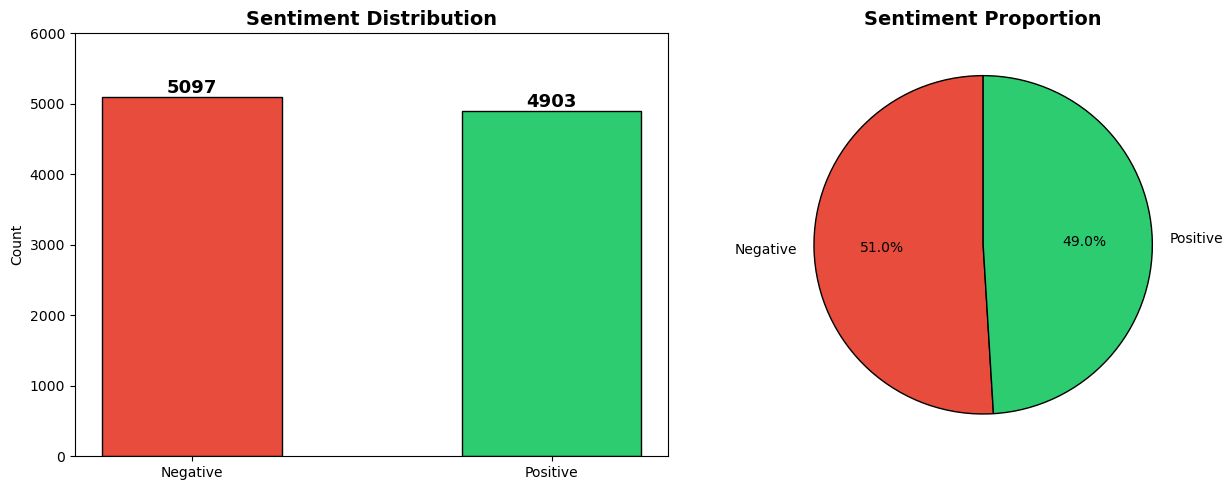

In [5]:
label_counts = df['label'].value_counts()
colors = ['#e74c3c', '#2ecc71']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(['Negative', 'Positive'], [label_counts['neg'], label_counts['pos']], color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 6000)
for i, v in enumerate([label_counts['neg'], label_counts['pos']]):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=13)
axes[1].pie([label_counts['neg'], label_counts['pos']], labels=['Negative', 'Positive'], colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='black'))
axes[1].set_title('Sentiment Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

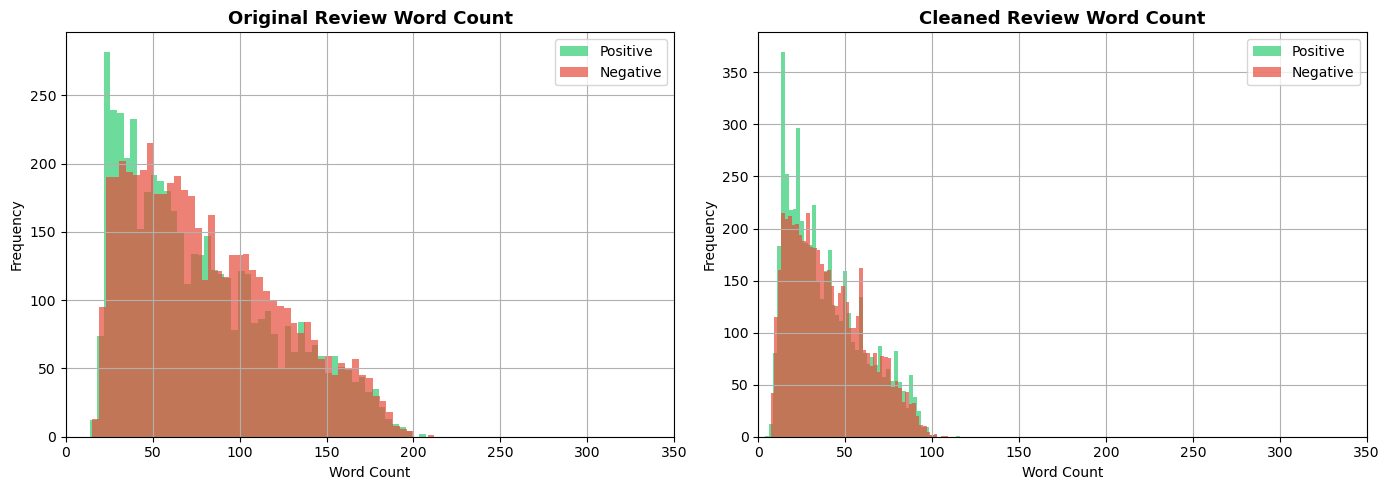

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ['review_length', 'clean_length'], ['Original Review Word Count', 'Cleaned Review Word Count']):
    df[df['label'] == 'pos'][col].hist(ax=ax, bins=50, alpha=0.7, color='#2ecc71', label='Positive')
    df[df['label'] == 'neg'][col].hist(ax=ax, bins=50, alpha=0.7, color='#e74c3c', label='Negative')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.set_xlim(0, 350)
plt.tight_layout()
plt.savefig('review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

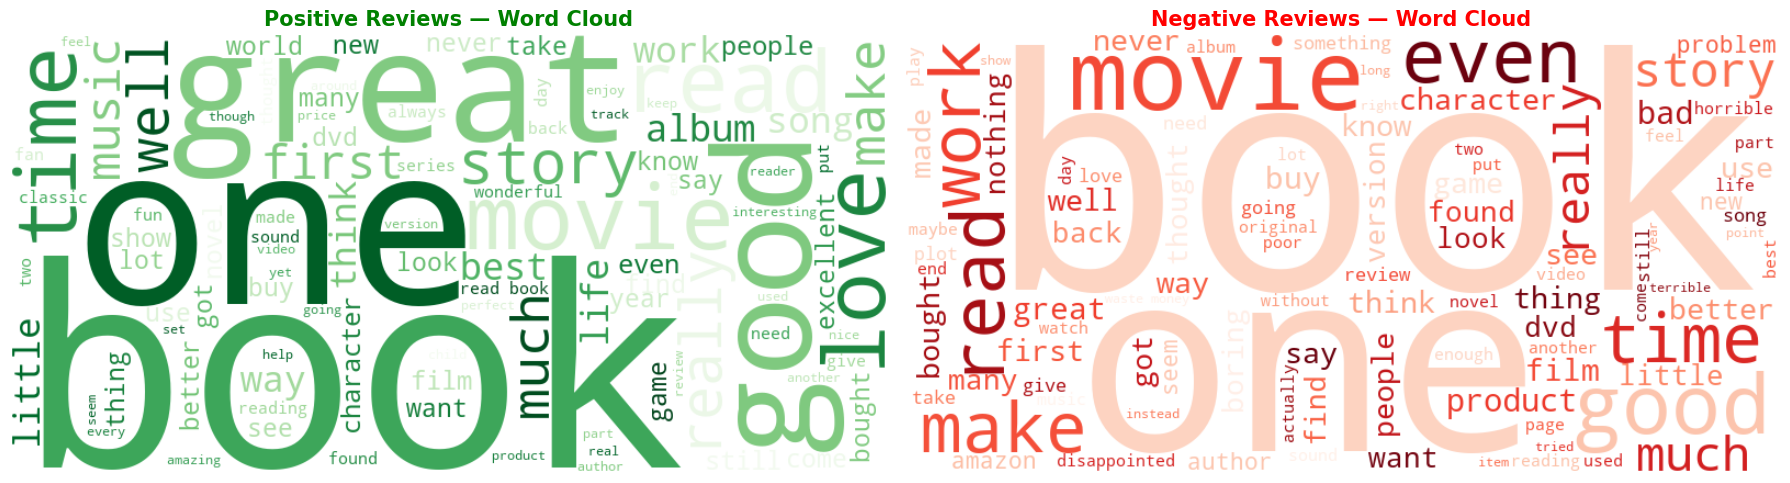

In [7]:
pos_text = ' '.join(df[df['label'] == 'pos']['clean_review'].tolist())
neg_text = ' '.join(df[df['label'] == 'neg']['clean_review'].tolist())
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(pos_text)
wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(neg_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews — Word Cloud', fontsize=15, fontweight='bold', color='green')
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews — Word Cloud', fontsize=15, fontweight='bold', color='red')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

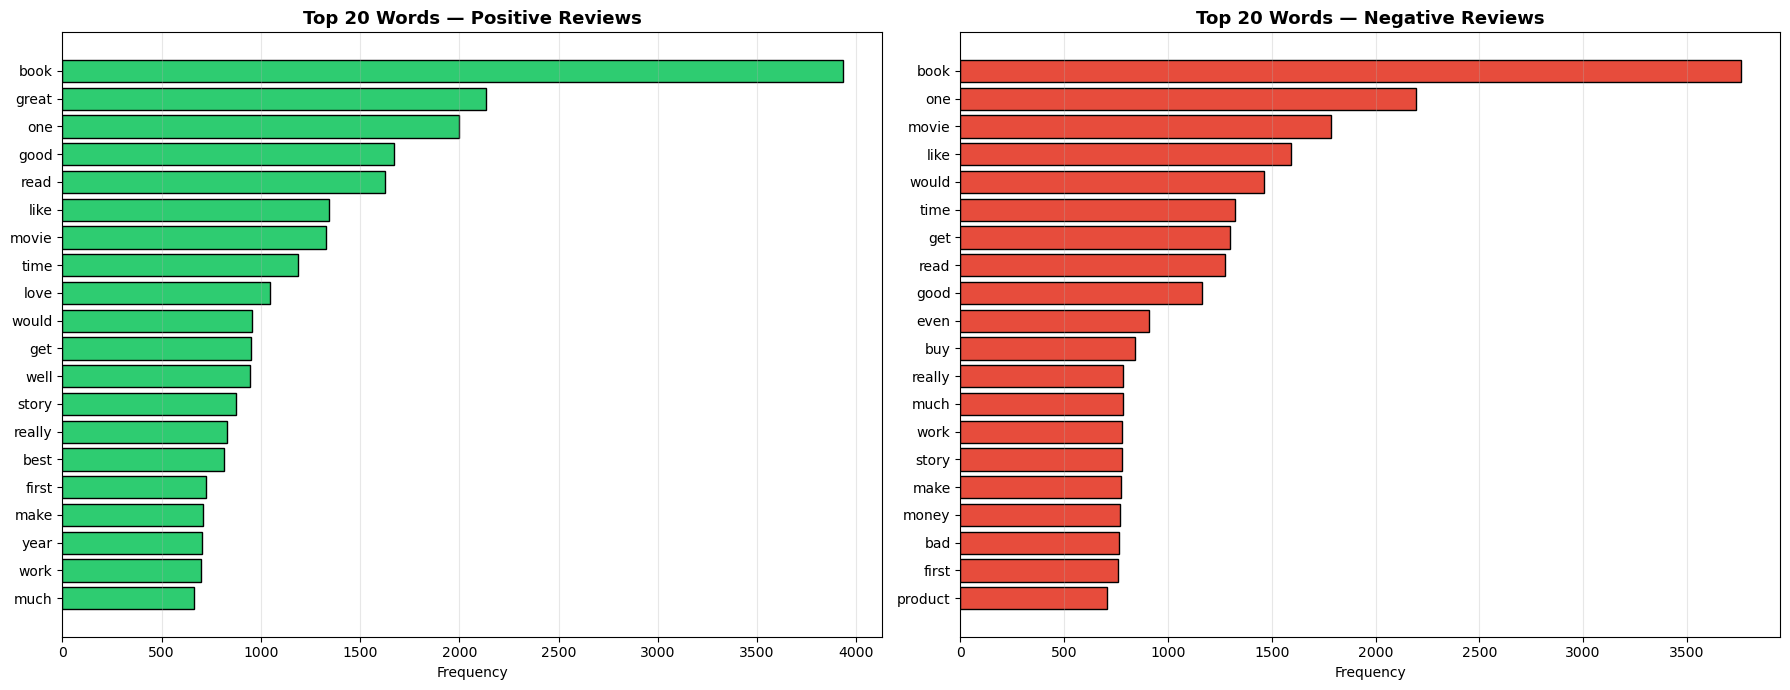

In [8]:
def top_words(series, n=20):
    all_words = ' '.join(series).split()
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, label, color in [(axes[0], 'pos', '#2ecc71'), (axes[1], 'neg', '#e74c3c')]:
    words, counts = zip(*top_words(df[df['label'] == label]['clean_review']))
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='black')
    ax.set_title(f'Top 20 Words — {"Positive" if label == "pos" else "Negative"} Reviews', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print("Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df['clean_review']
y = df['label_enc']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Train size: {X_train.shape[0]}")
print(f"Test  size: {X_test.shape[0]}")

Encoding: {'neg': np.int64(0), 'pos': np.int64(1)}
Train size: 8000
Test  size: 2000


In [10]:
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Train matrix:", X_train_tfidf.shape)
print("Test  matrix:", X_test_tfidf.shape)
print("Vocabulary  :", len(tfidf.vocabulary_))

Train matrix: (8000, 39474)
Test  matrix: (2000, 39474)
Vocabulary  : 39474


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42),
    'Linear SVM': LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Naive Bayes': MultinomialNB(alpha=0.1)
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    rep = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'precision': round(rep['weighted avg']['precision'], 4),
        'recall': round(rep['weighted avg']['recall'], 4),
        'f1': round(rep['weighted avg']['f1-score'], 4)
    }
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


  Logistic Regression
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85      1019
    Positive       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


  Linear SVM
              precision    recall  f1-score   support

    Negative       0.87      0.86      0.86      1019
    Positive       0.85      0.86      0.86       981

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000


  Naive Bayes
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.84      1019
    Positive       0.84      0.83      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.8

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for name, model in models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)),
        ('clf', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s}: CV Accuracy = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression   : CV Accuracy = 0.8645 ± 0.0069
Linear SVM            : CV Accuracy = 0.8680 ± 0.0062
Naive Bayes           : CV Accuracy = 0.8514 ± 0.0060


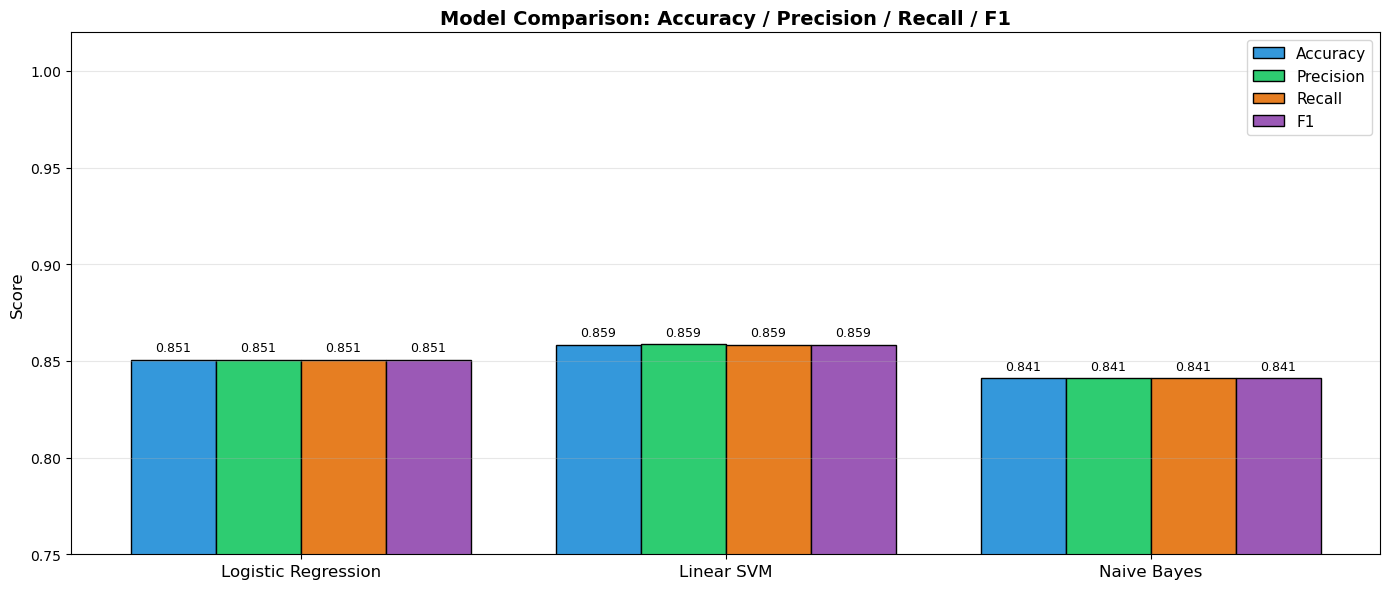

In [13]:
model_names = list(results.keys())
metrics_names = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(model_names))
w = 0.2
bar_colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics_names):
    vals = [results[n][metric] for n in model_names]
    bars = ax.bar(x + i * w - 1.5 * w, vals, w, label=metric.capitalize(), color=bar_colors[i], edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0.75, 1.02)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Accuracy / Precision / Recall / F1', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

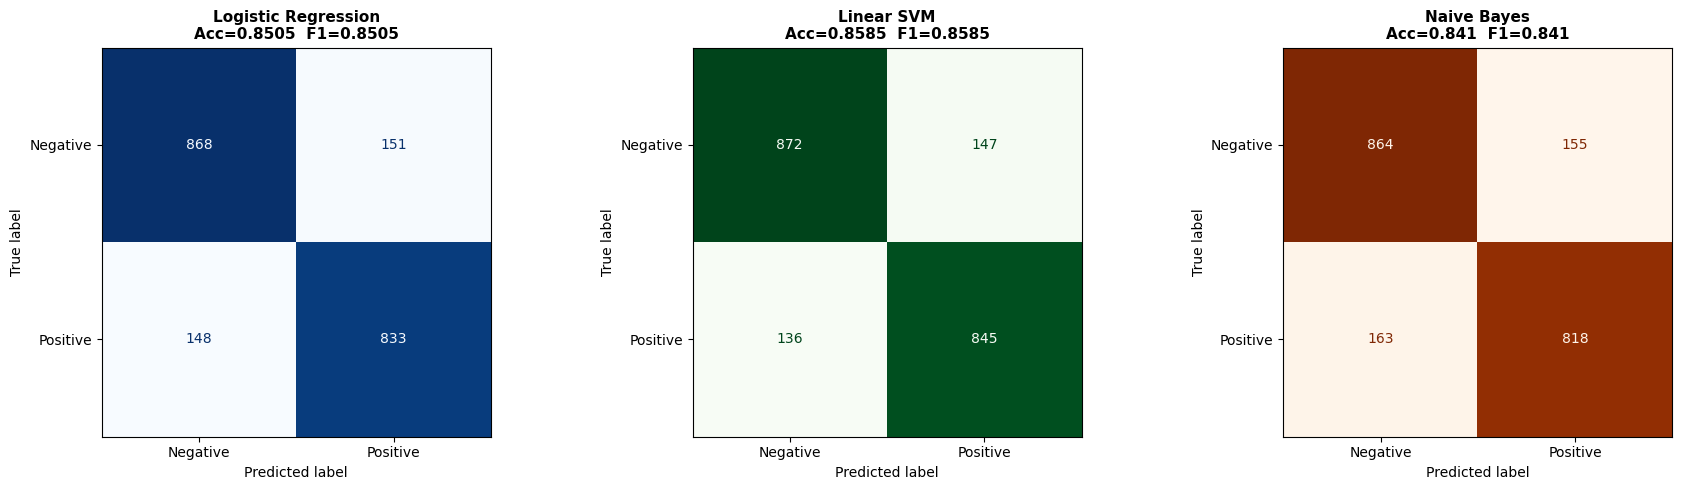

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res), cmap in zip(axes, results.items(), ['Blues', 'Greens', 'Oranges']):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{name}\nAcc={res["accuracy"]}  F1={res["f1"]}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

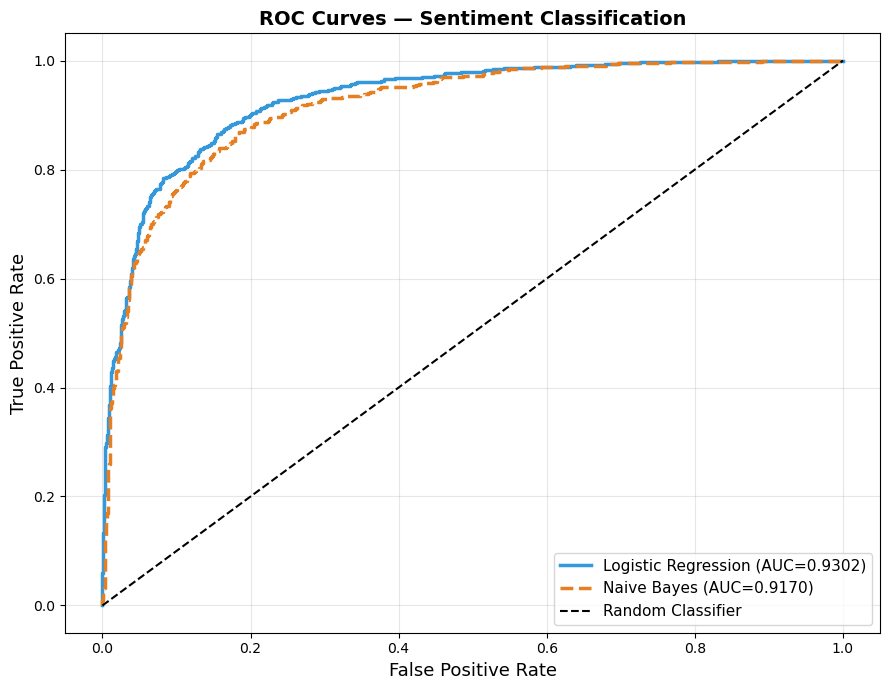

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
for name, color, ls in [('Logistic Regression', '#3498db', '-'), ('Naive Bayes', '#e67e22', '--')]:
    proba = results[name]['model'].predict_proba(X_test_tfidf)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2.5, linestyle=ls)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — Sentiment Classification', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
best_model = results['Linear SVM']['model']

def predict_sentiment(reviews):
    cleaned = [preprocess_text(r) for r in reviews]
    vec     = tfidf.transform(cleaned)
    preds   = best_model.predict(vec)
    return ['✅ POSITIVE' if p == 1 else '❌ NEGATIVE' for p in preds]

new_reviews = [
    "This product is absolutely amazing! Best purchase I ever made.",
    "Terrible quality. It broke after one day. Total waste of money.",
    "Decent product, nothing special but works fine for the price.",
    "I love this! Would definitely recommend to all my friends.",
    "Complete garbage. Do not buy this. Very disappointed."
]

predictions = predict_sentiment(new_reviews)
print("Live Sentiment Predictions:")
print("-" * 70)
for rev, pred in zip(new_reviews, predictions):
    print(f"{pred}  →  \"{rev[:65]}\"")

Live Sentiment Predictions:
----------------------------------------------------------------------
✅ POSITIVE  →  "This product is absolutely amazing! Best purchase I ever made."
❌ NEGATIVE  →  "Terrible quality. It broke after one day. Total waste of money."
❌ NEGATIVE  →  "Decent product, nothing special but works fine for the price."
✅ POSITIVE  →  "I love this! Would definitely recommend to all my friends."
❌ NEGATIVE  →  "Complete garbage. Do not buy this. Very disappointed."
